## **Implementasi Random Forest Classifier dengan Scikit Learn**

*sumber: GeeksforGeeks*

In [ ]:
import pandas as pd # untuk manipulasi dataframe            
import matplotlib.pyplot as plt # untuk visualisasi
import seaborn as sns # advance visualisasi
import sklearn # package utama machine learning

from sklearn.model_selection import train_test_split # untuk splitting data
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # untuk evaluasi
from sklearn.ensemble import RandomForestClassifier # model utama Random Forest Classifier
from sklearn.datasets import load_iris # data bunga iris

In [2]:
# Import Dataset
''' 
Mengambil Dataset dari Scikit Learn: Dataset bunga iris
'''
iris = load_iris() 
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# Memisahkan fitur dependen(target) dan independen(variabel karakter)
X = df.drop(columns=['target'])
y = df['target']

In [5]:
# Splitting to data train dan data test
''' 
Pembagian data:
Data Train = 80%
Data Test = 20%
'''
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Random Forest Classification Process
'''
Tahapan:
1. Inisialisasi model Random Forest
2. Fit(latih) ke data training
3. Gunakan model yang sudah dilatih untuk memprediksi data testing
'''
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

Accuracy: 100.00%


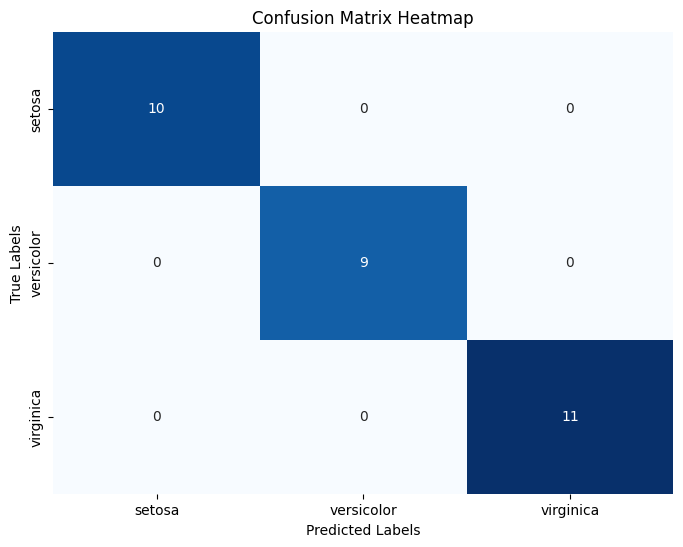

In [7]:
# Evaluasi
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=iris.target_names, yticklabels=iris.target_names)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [8]:
# Classification Report
print(f"Classification Report: \n")
print(classification_report(y_test, y_pred))

Classification Report: 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#### **catatan :** 

Implementasi ini menggunakan data Iris yang sudah bersih (dari Scikit Learn). Oleh karena itu, hasil prediksi bisa pure mencapai 100%. Apabila kamu menggunakan data lain yang masih kotor dari open source, ada kemungkinan akurasi tidak akan mencapai 100% tanpa pre-processing yang maksimal.